# Data Preparation

In [1]:
import os
import pandas as pd
import numpy as np

data_dir = "../data"
file_paths = {
    "presentations_df": os.path.join(data_dir, "presentations_df.csv"),
    "user_profiles": os.path.join(data_dir, "user_profiles.csv"),
    "user_profiles_flat": os.path.join(data_dir, "user_profiles_flat.csv"),
    "recommendations": os.path.join(data_dir, "recommendations.csv"),
    "ratings_matrix": os.path.join(data_dir, "ratings_matrix.csv"),
    "interaction_data": os.path.join(data_dir, "interaction_data.csv"),
    "X": os.path.join(data_dir, "X.csv"),
    "y": os.path.join(data_dir, "y.csv"),
    "feature_columns": os.path.join(data_dir, "feature_columns.txt")
}

def safe_read_csv(path, name):
    if os.path.exists(path):
        return pd.read_csv(path)
    else:
        print(f"⚠️ File not found: {name} -> {path}")
        return None

# Load all CSVs
presentations_df = safe_read_csv(file_paths["presentations_df"], "presentations_df")
user_profiles = safe_read_csv(file_paths["user_profiles"], "user_profiles")
user_profiles_flat = safe_read_csv(file_paths["user_profiles_flat"], "user_profiles_flat")
recommendations = safe_read_csv(file_paths["recommendations"], "recommendations")
ratings_matrix = safe_read_csv(file_paths["ratings_matrix"], "ratings_matrix")
interaction_data = safe_read_csv(file_paths["interaction_data"], "interaction_data")

# Load X and y
X_df = safe_read_csv(file_paths["X"], "X")
X = X_df.values if X_df is not None else None

y_df = safe_read_csv(file_paths["y"], "y")
y = y_df.values.flatten() if y_df is not None else None

# Load feature columns
if os.path.exists(file_paths["feature_columns"]):
    with open(file_paths["feature_columns"], "r") as f:
        feature_columns = [line.strip() for line in f]
else:
    print(f"⚠️ File not found: feature_columns.txt -> {file_paths['feature_columns']}")
    feature_columns = None


In [2]:
import nbimporter
from dataset_generator import prepare_recommendation_system_input_data  # use any function or class from that notebook
from utils_notebook import evaluate_regression_model 

# Data Preparation

In [3]:

# import pandas as pd

# # Convert timestamp to datetime format
# interaction_data["timestamp"] = pd.to_datetime(interaction_data["timestamp"])

# # Compute time_since in hours from the most recent timestamp
# max_timestamp = interaction_data["timestamp"].max()
# interaction_data["time_since"] = (max_timestamp - interaction_data["timestamp"]).dt.total_seconds() / 3600
# ######### time_since become days_since_last_rating

In [4]:
user_features_names=['user_preference_Boring presentation',
 'user_preference_Graphics',
 'user_preference_Readability',
 'user_preference_Consistency',
 'user_preference_Images',
 'user_preference_Bullets',
 'user_preference_Text size',
 'user_preference_Text heavy',
 'user_preference_Tables',
 'user_preference_Agenda',
 'user_preference_Infographics',
 'user_preference_Positioning',
 'user_preference_Presentation length',
 'user_preference_General tips',
 'user_preference_Presentation skills',
 'user_preference_Powerpoint knowledge',
 'user_preference_tips and tricks',
 'user_preference_Explanation of the problem',
 'user_type_business',
 'user_type_teacher',
 'user_type_student',
 'user_type_researcher',
 'user_type_manager',
 'user_type_technical',
 'user_type_specialist',
 'presentation_type_formal_x',
 'presentation_type_creative_x',
 'presentation_type_students_x',
 'presentation_type_technical_x',
 'presentation_type_branding_x']
item_features_names=[ 'Boring presentation',
 'Graphics',
 'Readability',
 'Consistency',
 'Images',
 'Bullets',
 'Text size',
 'Text heavy',
 'Tables',
 'Agenda',
 'Infographics',
 'Positioning',
 'Presentation length',
 'General tips',
 'Presentation skills',
 'Powerpoint knowledge',
 'tips and tricks',
 'Explanation of the problem',
 'presentation_type_formal_y',
 'presentation_type_creative_y',
 'presentation_type_students_y',
 'presentation_type_technical_y',
 'presentation_type_branding_y',
 'audience_type_academic',
 'audience_type_business',
 'audience_type_kids',
 'audience_type_general',
 'audience_type_creative',
 'audience_type_specialized']


In [5]:
import numpy as np
import pandas as pd


interaction_data = interaction_data.sort_values(by=['user_id', 'article_id']).reset_index(drop=True)

def extract_time_features(dates, start_time):
    # Convert to datetime with UTC if not already
    df_temp = pd.DataFrame({'Datetime': pd.to_datetime(dates, errors='coerce')})

    # Ensure timezone awareness (UTC)
    if df_temp['Datetime'].dt.tz is None:
        df_temp['Datetime'] = df_temp['Datetime'].dt.tz_localize('UTC')
    else:
        df_temp['Datetime'] = df_temp['Datetime'].dt.tz_convert('UTC')

    # Ensure start_time is timezone-aware
    start_time = pd.to_datetime(start_time, utc=True)

    # Sort values
    df_temp = df_temp.sort_values(by='Datetime').reset_index(drop=True)

    # Extract cyclical time features
    df_temp['Hour'] = df_temp['Datetime'].dt.hour
    df_temp['Day_of_Week'] = df_temp['Datetime'].dt.dayofweek
    df_temp['Hour_sin'] = np.sin(2 * np.pi * df_temp['Hour'] / 24)
    df_temp['Hour_cos'] = np.cos(2 * np.pi * df_temp['Hour'] / 24)
    df_temp['Day_sin'] = np.sin(2 * np.pi * df_temp['Day_of_Week'] / 7)
    df_temp['Day_cos'] = np.cos(2 * np.pi * df_temp['Day_of_Week'] / 7)

    # Time since first submission in hours
    df_temp['Time_since_first_submission_hours'] = (
        (df_temp['Datetime'] - start_time).dt.total_seconds() / 3600
    ).astype(np.float32)

    return df_temp[['Hour_sin', 'Hour_cos', 'Day_sin', 'Day_cos', 'Time_since_first_submission_hours']]

# Ensure start_time is timezone-aware
start_time = pd.to_datetime("2005-12-01 00:00:00", utc=True)

# Apply time feature extraction to interaction and presentation data
time_features = extract_time_features(interaction_data['timestamp'], start_time)

user_features = interaction_data[user_features_names]
item_features = interaction_data[item_features_names]
X_user_id = interaction_data['user_id']
X_item_id = interaction_data['article_id']

# Problem features
problem_features = [
    'Boring presentation', 'Graphics', 'Readability', 'Consistency',
    'Images', 'Bullets', 'Text size', 'Text heavy', 'Tables',
    'Agenda', 'Infographics', 'Positioning'
]

# Process presentation features and timestamps
presentation_df_temp = presentations_df.sort_values(by='user_id').reset_index(drop=True)
presentation_submission_date_df = extract_time_features(presentation_df_temp['submission_date'], start_time)

# Concatenate user_id, problem features, and time features
problem_sequences_df = pd.concat(
    [presentations_df['user_id'], presentations_df[problem_features], presentation_submission_date_df],
    axis=1
)

y = interaction_data['rating']


In [7]:
problem_sequences_df[problem_sequences_df['user_id']==1]

,user_id,Boring presentation,Graphics,Readability,Consistency,Images,Bullets,Text size,Text heavy,Tables,Agenda,Infographics,Positioning,Hour_sin,Hour_cos,Day_sin,Day_cos,Time_since_first_submission_hours
0,1,0,1,1,0,1,0,0,1,0,0,1,0,0.258819,0.965926,-0.433884,-0.900969,14137.0


In [8]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

def calculate_problem_weights(df, date_column, problem_columns, days_window=90, decay_factor=0.01, apply_filter=True):
    """
    Изчислява претеглена вероятност за всеки проблем на база на презентации от последните days_window дни.
    
    Важно: Колоната, зададена с date_column, съдържа време в часове от първата подадена презентация.
    
    :param df: DataFrame с колоните [date_column] и [problem_columns]
    :param date_column: Име на колоната, която съдържа времето (в часове) от първата submission.
    :param problem_columns: Списък с колоните за проблемите (0 или 1)
    :param days_window: Колко дни назад да се вземат презентации (по подразбиране 90 дни)
    :param decay_factor: Фактор на затихване (по подразбиране 0.01)
    :param apply_filter: Ако True, филтрира по времевия прозорец. Ако False, използва целия DataFrame.
    :return: df_filtered (или оригиналния df ако не се филтрира) и NumPy масив с претеглените стойности за всеки проблем.
    """
    
    # Ако DataFrame има само един ред, връщаме директно неговите стойности.
    if len(df) <= 1:
        arr = np.array([df[col].iloc[0] if not df.empty else 0 for col in problem_columns])
        return df, arr

    # Ако apply_filter е True, филтрираме редовете според времевия прозорец.
    # Изчисляваме прага в часове (дни_window * 24)
    if apply_filter:
        threshold_hours = days_window * 24
        df_filtered = df[df[date_column] <= threshold_hours]
    else:
        df_filtered = df.copy()

    # Ако след филтрирането няма редове, връщаме масив със 0 стойности.
    if df_filtered.empty:
        print("No data after filtering. Returning zeros.")
        return df, np.array([0 for _ in problem_columns])
    
    # Изчисляване на тежестите спрямо възрастта на презентациите.
    # Тъй като колоната е в часове, преобразуваме часовете в дни (делим на 24)
    # за да запазим decay_factor, дефиниран за дни.
    df_filtered["weight"] = np.exp(-decay_factor * (df_filtered[date_column] / 24))
    
    # Изчисляване на претегленото средно за всеки проблем
    weighted_problems = np.array([
        (df_filtered[col] * df_filtered["weight"]).sum() / df_filtered["weight"].sum() 
        for col in problem_columns
    ])
    
    return df_filtered, weighted_problems

padded_problem_sequences = []
user_data = {}

for user_id_to_fetch in X_user_id:
    if user_id_to_fetch in user_data:
        # If user data is already calculated, use it directly
        weighted_problems = user_data[user_id_to_fetch]
    else:
        # Filter the DataFrame for the current user
        df_user = problem_sequences_df[problem_sequences_df['user_id'] == user_id_to_fetch]
        # Calculate weighted problems
        _, weighted_problems = calculate_problem_weights(df_user, 
                                                          "Time_since_first_submission_hours", 
                                                          problem_features, 
                                                          days_window=180, 
                                                          decay_factor=0.01, 
                                                          apply_filter=False)
        
        # Store the result in user_data
        user_data[user_id_to_fetch] = weighted_problems
    
    # Append to padded_problem_sequences
    padded_problem_sequences.append(weighted_problems)
    
padded_problem_sequences = np.array(padded_problem_sequences)

# If it's 1D  reshape to 2D Keras typically expects a 2D tensor for each input, where:The first dimension (axis 0) represents the number of samples in the batch.The second dimension (axis 1) represents the features for each sample.
if len(padded_problem_sequences.shape) == 1:
    padded_problem_sequences = padded_problem_sequences.reshape(-1, 1)

padded_problem_sequences


array([[0., 1., 1., ..., 0., 1., 0.],
       [0., 1., 1., ..., 0., 1., 0.],
       [0., 1., 1., ..., 0., 1., 0.],
       ...,
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.]])

In [9]:
# Verify lengths
print("X_user_id:", len(X_user_id))
print("X_item_id:", len(X_item_id))
print("time_features:", len(time_features))
print("padded_problem_sequences:", len(padded_problem_sequences))
print("user_features:", len(user_features))
print("item_features:", len(item_features))
print("y:", len(y))  # Ensure y also has 25,000 elements

X_user_id: 3000
X_item_id: 3000
time_features: 3000
padded_problem_sequences: 3000
user_features: 3000
item_features: 3000
y: 3000


In [11]:
from sklearn.model_selection import train_test_split
import numpy as np

# Ensure all feature lists have consistent length
assert len(X_user_id) == len(X_item_id) == len(time_features) == len(padded_problem_sequences) == len(user_features) == len(item_features) == len(y), "Feature lengths do not match!"

# Split data into train (70%) and temp (30%)
X_user_id_train, X_user_id_temp, \
X_item_id_train, X_item_id_temp, \
time_features_train, time_features_temp, \
padded_problem_sequences_train, padded_problem_sequences_temp, \
user_features_train, user_features_temp, \
item_features_train, item_features_temp, \
y_train, y_temp = train_test_split(
    X_user_id, X_item_id, time_features, padded_problem_sequences, user_features, item_features, y, 
    test_size=0.3, random_state=42
)

# Split temp into validation (15%) and test (15%)
X_user_id_val, X_user_id_test, \
X_item_id_val, X_item_id_test, \
time_features_val, time_features_test, \
padded_problem_sequences_val, padded_problem_sequences_test, \
user_features_val, user_features_test, \
item_features_val, item_features_test, \
y_val, y_test = train_test_split(
    X_user_id_temp, X_item_id_temp, time_features_temp, padded_problem_sequences_temp, 
    user_features_temp, item_features_temp, y_temp, 
    test_size=0.5, random_state=42
)

# Convert lists to NumPy arrays for easier processing
train_user_features = np.array(user_features_train)
train_item_features = np.array(item_features_train)
train_time_features = np.array(time_features_train)
train_problem_seq = np.array(padded_problem_sequences_train)
train_labels = np.array(y_train)

val_user_features = np.array(user_features_val)
val_item_features = np.array(item_features_val)
val_time_features = np.array(time_features_val)
val_problem_seq = np.array(padded_problem_sequences_val)
val_labels = np.array(y_val)

test_user_features = np.array(user_features_test)
test_item_features = np.array(item_features_test)
test_time_features = np.array(time_features_test)
test_problem_seq = np.array(padded_problem_sequences_test)
test_labels = np.array(y_test)

# Print dataset sizes to confirm
print(f"Train size: {len(train_labels)}")
print(f"Validation size: {len(val_labels)}")
print(f"Test size: {len(test_labels)}")
print("✅ Data successfully split into train, validation, and test sets!")


Train size: 2100
Validation size: 450
Test size: 450
✅ Data successfully split into train, validation, and test sets!


In [20]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import kerastuner as kt

def model_builder(hp):
    """
    Builds a model with hyperparameters chosen by Keras Tuner.
    
    Assumes that the following global variables exist and define the input shapes:
      - user_features, item_features, time_features, padded_problem_sequences
      
    These should be NumPy arrays (or at least their shapes are known).
    """
    # Define input layers (using global shape information)
    user_feat_in = Input(shape=(user_features.shape[1],), name="user_feat_input")
    item_feat_in = Input(shape=(item_features.shape[1],), name="item_feat_input")
    time_in = Input(shape=(time_features.shape[1],), name="time_input")
    problem_seq_in = Input(shape=(padded_problem_sequences.shape[1],), name="problem_seq_input")
    
    # Regularization strength fixed (you could also tune this if desired)
    regularizer = l2(1e-4)
    
    # ----- User Tower -----
    user_units = hp.Choice('user_units', values=[64, 128, 256], default=128)
    user_dropout = hp.Float('user_dropout', min_value=0.2, max_value=0.5, step=0.1, default=0.3)
    x_user = Dense(user_units, activation="relu", kernel_regularizer=regularizer)(user_feat_in)
    x_user = BatchNormalization()(x_user)
    x_user = Dropout(user_dropout)(x_user)
    user_emb_units = hp.Choice('user_emb_units', values=[16, 32, 64], default=32)
    user_emb = Dense(user_emb_units, activation="relu", kernel_regularizer=regularizer, name="user_embedding")(x_user)
    
    # ----- Item Tower -----
    item_units = hp.Choice('item_units', values=[64, 128, 256], default=128)
    item_dropout = hp.Float('item_dropout', min_value=0.2, max_value=0.5, step=0.1, default=0.3)
    x_item = Dense(item_units, activation="relu", kernel_regularizer=regularizer)(item_feat_in)
    x_item = BatchNormalization()(x_item)
    x_item = Dropout(item_dropout)(x_item)
    item_emb_units = hp.Choice('item_emb_units', values=[16, 32, 64], default=32)
    item_emb = Dense(item_emb_units, activation="relu", kernel_regularizer=regularizer, name="item_embedding")(x_item)
    
    # ----- Temporal Features Tower -----
    time_units = hp.Choice('time_units', values=[8, 16, 32], default=16)
    time_dropout = hp.Float('time_dropout', min_value=0.1, max_value=0.3, step=0.1, default=0.2)
    x_time = Dense(time_units, activation="relu", kernel_regularizer=regularizer)(time_in)
    x_time = BatchNormalization()(x_time)
    x_time = Dropout(time_dropout)(x_time)
    
    # ----- Problem Sequence Tower -----
    problem_units = hp.Choice('problem_units', values=[32, 64, 128], default=64)
    problem_dropout = hp.Float('problem_dropout', min_value=0.2, max_value=0.5, step=0.1, default=0.3)
    x_problem = Dense(problem_units, activation="relu", kernel_regularizer=regularizer)(problem_seq_in)
    x_problem = BatchNormalization()(x_problem)
    x_problem = Dropout(problem_dropout)(x_problem)
    problem_emb_units = hp.Choice('problem_emb_units', values=[16, 32, 64], default=32)
    problem_emb = Dense(problem_emb_units, activation="relu", kernel_regularizer=regularizer)(x_problem)
    
    # ----- Merge Towers -----
    merged = Concatenate()([user_emb, item_emb, x_time, problem_emb])
    merged_units = hp.Choice('merged_units', values=[32, 64, 128], default=64)
    x = Dense(merged_units, activation="relu", kernel_regularizer=regularizer)(merged)
    x = BatchNormalization()(x)
    merged_dropout = hp.Float('merged_dropout', min_value=0.2, max_value=0.5, step=0.1, default=0.4)
    x = Dropout(merged_dropout)(x)
    second_merged_units = hp.Choice('merged_units2', values=[16, 32, 64], default=32)
    x = Dense(second_merged_units, activation="relu", kernel_regularizer=regularizer)(x)
    
    # Final output layer (regression)
    output = Dense(1, activation="linear")(x)
    
    model = Model(inputs=[user_feat_in, item_feat_in, time_in, problem_seq_in], outputs=output)
    
    # Tune the learning rate as well
    learning_rate = hp.Float('learning_rate', min_value=1e-5, max_value=1e-3, sampling='LOG', default=5e-4)
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mse", metrics=["mae"])
    
    return model

# Define a Hyperband tuner (you can also use RandomSearch or BayesianOptimization)
tuner = kt.Hyperband(
    model_builder,
    objective='val_loss',
    max_epochs=50,
    factor=3,
    directory='my_tuner',
    project_name='multy_tower_search'
)

# Callback to stop early if no improvement
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)

# Assume you have your training and validation data prepared as NumPy arrays:
# For example:
#   train_user_features, train_item_features, train_time_features, train_problem_seq, train_labels
#   val_user_features, val_item_features, val_time_features, val_problem_seq, val_labels

# Start the hyperparameter search
tuner.search(
    [train_user_features, train_item_features, train_time_features, train_problem_seq],
    train_labels,
    epochs=50,
    validation_data=(
        [val_user_features, val_item_features, val_time_features, val_problem_seq],
        val_labels
    ),
    callbacks=[stop_early]
)

# Retrieve the best model.
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:")
print(best_hps.values)

INFO:tensorflow:Reloading Oracle from existing project my_tuner\multy_tower_search\oracle.json
INFO:tensorflow:Reloading Tuner from my_tuner\multy_tower_search\tuner0.json
INFO:tensorflow:Oracle triggered exit
Best hyperparameters:
{'user_units': 128, 'user_dropout': 0.30000000000000004, 'user_emb_units': 16, 'item_units': 128, 'item_dropout': 0.30000000000000004, 'item_emb_units': 16, 'time_units': 8, 'time_dropout': 0.1, 'problem_units': 32, 'problem_dropout': 0.5000000000000001, 'problem_emb_units': 32, 'merged_units': 32, 'merged_dropout': 0.2, 'merged_units2': 32, 'learning_rate': 0.0009616137548745257, 'tuner/epochs': 50, 'tuner/initial_epoch': 17, 'tuner/bracket': 2, 'tuner/round': 2, 'tuner/trial_id': 'b5209c8832ddbbac389bfba769f0deeb'}
Epoch 1/200
64/64 [==============================] - 2s 16ms/step - loss: 7.7314 - mae: 2.4899 - val_loss: 6.0181 - val_mae: 2.2871
Epoch 2/200
64/64 [==============================] - 1s 12ms/step - loss: 1.8778 - mae: 1.0986 - val_loss: 2.6772

#BUild a model without a tuner to fit the article

In [21]:
best_hps ={
    'user_units': 128,                     # User Tower: Dense 128
    'user_dropout': 0.3,
    'user_emb_units': 16,

    'item_units': 256,                     # Item Tower: Dense 256 (updated to match article)
    'item_dropout': 0.3,
    'item_emb_units': 16,

    'time_units': 16,                      # Time Tower: Dense 16 (updated)
    'time_dropout': 0.1,

    'problem_units': 32,                   # Problem Tower: Dense 32 (already matches)
    'problem_dropout': 0.5,
    'problem_emb_units': 32,

    'merged_units': 128,                   # After Concatenation: Dense 128 (updated)
    'merged_dropout': 0.2,
    'merged_units2': 32,                   # Second merged layer: Dense 32 (already matches)

    'learning_rate': 0.001,

    'tuner/epochs': 50,
    'tuner/initial_epoch': 17,
    'tuner/bracket': 2,
    'tuner/round': 2,
    'tuner/trial_id': 'b5209c8832ddbbac389bfba769f0deeb'
}


from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

def build_model_from_best_hps(best_hps, input_shapes):
    reg = l2(1e-4)

    # Input shapes
    user_input = Input(shape=(input_shapes['user'],), name="user_feat_input")
    item_input = Input(shape=(input_shapes['item'],), name="item_feat_input")
    time_input = Input(shape=(input_shapes['time'],), name="time_input")
    problem_input = Input(shape=(input_shapes['problem'],), name="problem_seq_input")

    # User tower
    x_user = Dense(best_hps['user_units'], activation="relu", kernel_regularizer=reg)(user_input)
    x_user = BatchNormalization()(x_user)
    x_user = Dropout(best_hps['user_dropout'])(x_user)
    user_emb = Dense(best_hps['user_emb_units'], activation="relu", kernel_regularizer=reg)(x_user)

    # Item tower
    x_item = Dense(best_hps['item_units'], activation="relu", kernel_regularizer=reg)(item_input)
    x_item = BatchNormalization()(x_item)
    x_item = Dropout(best_hps['item_dropout'])(x_item)
    item_emb = Dense(best_hps['item_emb_units'], activation="relu", kernel_regularizer=reg)(x_item)

    # Time tower
    x_time = Dense(best_hps['time_units'], activation="relu", kernel_regularizer=reg)(time_input)
    x_time = BatchNormalization()(x_time)
    x_time = Dropout(best_hps['time_dropout'])(x_time)

    # Problem tower
    x_problem = Dense(best_hps['problem_units'], activation="relu", kernel_regularizer=reg)(problem_input)
    x_problem = BatchNormalization()(x_problem)
    x_problem = Dropout(best_hps['problem_dropout'])(x_problem)
    problem_emb = Dense(best_hps['problem_emb_units'], activation="relu", kernel_regularizer=reg)(x_problem)

    # Merge
    merged = Concatenate()([user_emb, item_emb, x_time, problem_emb])
    x = Dense(best_hps['merged_units'], activation="relu", kernel_regularizer=reg)(merged)
    x = BatchNormalization()(x)
    x = Dropout(best_hps['merged_dropout'])(x)
    x = Dense(best_hps['merged_units2'], activation="relu", kernel_regularizer=reg)(x)
    
    # Output
    output = Dense(1, activation="linear")(x)

    model = Model(inputs=[user_input, item_input, time_input, problem_input], outputs=output)
    model.compile(optimizer=Adam(learning_rate=best_hps['learning_rate']), loss="mse", metrics=["mae"])
    
    return model

from sklearn.model_selection import KFold
import numpy as np
import time

# Step 1: Combine train and validation sets
X_user_all = np.concatenate([train_user_features, val_user_features], axis=0)
X_item_all = np.concatenate([train_item_features, val_item_features], axis=0)
X_time_all = np.concatenate([train_time_features, val_time_features], axis=0)
X_problem_seq_all = np.concatenate([train_problem_seq, val_problem_seq], axis=0)
y_all = np.concatenate([train_labels, val_labels], axis=0)

# Step 2: Set up K-Fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Step 3: Track histories
history_list = []

# Step 4: Start timing
start_time = time.time()

# Step 5: Cross-validation loop
for train_index, val_index in kf.split(X_user_all):
    train_user_fold, val_user_fold = X_user_all[train_index], X_user_all[val_index]
    train_item_fold, val_item_fold = X_item_all[train_index], X_item_all[val_index]
    train_time_fold, val_time_fold = X_time_all[train_index], X_time_all[val_index]
    train_problem_seq_fold, val_problem_seq_fold = X_problem_seq_all[train_index], X_problem_seq_all[val_index]
    train_labels_fold, val_labels_fold = y_all[train_index], y_all[val_index]
    input_shapes = {
    'user': train_user_fold.shape[1],
    'item': train_item_fold.shape[1],
    'time': train_time_fold.shape[1],
    'problem': train_problem_seq_fold.shape[1]
    }

    best_rs_model = build_model_from_best_hps(best_hps, input_shapes)

    # Fit model
    history = best_rs_model.fit(
        [train_user_fold, train_item_fold, train_time_fold, train_problem_seq_fold],
        train_labels_fold,
        validation_data=(
            [val_user_fold, val_item_fold, val_time_fold, val_problem_seq_fold],
            val_labels_fold
        ),
        epochs=200,
        batch_size=32,
        callbacks=[stop_early]
    )

    history_list.append(history)

# Step 6: Aggregate results
average_val_loss = np.mean([h.history['val_loss'][-1] for h in history_list])
average_val_mae = np.mean([h.history['val_mae'][-1] for h in history_list])

# Step 7: Print results
print(f"\nAverage Validation Loss: {average_val_loss:.4f}")
print(f"Average Validation MAE: {average_val_mae:.4f}")

# Step 8: Print timing
end_time = time.time()
print(f"✅ Total Execution Time: {end_time - start_time:.2f} seconds")

Epoch 1/200
64/64 [==============================] - 2s 16ms/step - loss: 2.0687 - mae: 1.1176 - val_loss: 2.5998 - val_mae: 1.3458
Epoch 2/200
64/64 [==============================] - 1s 12ms/step - loss: 1.0240 - mae: 0.7987 - val_loss: 2.2580 - val_mae: 1.2554
Epoch 3/200
64/64 [==============================] - 1s 12ms/step - loss: 0.8307 - mae: 0.7096 - val_loss: 1.0239 - val_mae: 0.7341
Epoch 4/200
64/64 [==============================] - 1s 13ms/step - loss: 0.7638 - mae: 0.6736 - val_loss: 0.8746 - val_mae: 0.6809
Epoch 5/200
64/64 [==============================] - 1s 14ms/step - loss: 0.6780 - mae: 0.6331 - val_loss: 0.8686 - val_mae: 0.6358
Epoch 6/200
64/64 [==============================] - 1s 14ms/step - loss: 0.6486 - mae: 0.6231 - val_loss: 0.6364 - val_mae: 0.5912
Epoch 7/200
64/64 [==============================] - 1s 14ms/step - loss: 0.6141 - mae: 0.6035 - val_loss: 0.5300 - val_mae: 0.5589
Epoch 8/200
64/64 [==============================] - 1s 14ms/step - loss: 0.

In [22]:
# --- 9. Predict on validation data ---
y_pred = best_rs_model.predict([test_user_features, test_item_features, test_time_features, test_problem_seq])

In [23]:
best_rs_model.summary()

Model: "model_5"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
user_feat_input (InputLayer)    [(None, 30)]         0                                            
__________________________________________________________________________________________________
item_feat_input (InputLayer)    [(None, 29)]         0                                            
__________________________________________________________________________________________________
problem_seq_input (InputLayer)  [(None, 12)]         0                                            
__________________________________________________________________________________________________
dense_48 (Dense)                (None, 128)          3968        user_feat_input[0][0]            
____________________________________________________________________________________________

✅ Mean Absolute Error (MAE): 0.1331
✅ Mean Squared Error (MSE): 0.0363
✅ Root Mean Squared Error (RMSE): 0.1904
✅ R² Score: 0.9568


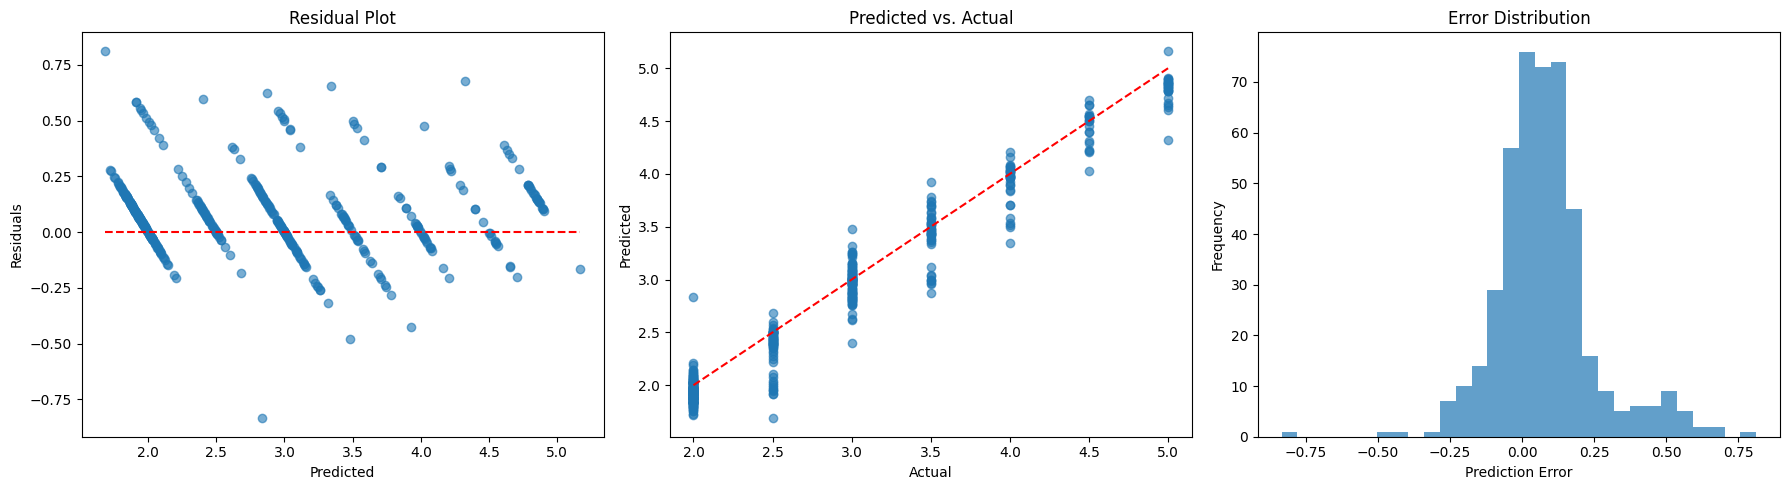

{'mae': 0.13313587692048814, 'mse': 0.03626964293442929, 'rmse': 0.1904459055333805, 'r2': 0.9567949298550423}


In [24]:
 # Ensure arrays are flattened for consistency
#y_pred = np.array(y_pred).flatten()
#y_test = np.array(y_test).flatten()
emdedding_model_results = evaluate_regression_model(y_test, y_pred, show_plots=True)
print(emdedding_model_results)

################ Get recommendations for specific user

In [46]:
import numpy as np

# --- Select the user with id 1 ---
# (Here we assume that user id 1 corresponds to index 1 in our arrays; adjust if needed.)
user_id = 1
######### only before prediction is the filtering-the training of model is on full datat
temp_df = interaction_data[
    (interaction_data['user_id'] == user_id) &
    (interaction_data['location'] != interaction_data['location_restrictions'])].copy()
user_features_df = temp_df[user_features_names]
item_features_df = temp_df[item_features_names]
start_time = pd.to_datetime("2005-12-01 00:00:00")
time_features_df = extract_time_features(temp_df['timestamp'], start_time)
problem_seq_df = problem_sequences_df[problem_sequences_df['user_id'] == user_id]

problem_sequences_features = []
user_data = {}
for i in range(len(user_features_df)):
    _, weighted_problems = calculate_problem_weights(df_user, "Time_since_first_submission_hours", problem_features, days_window=180, decay_factor=0.01, apply_filter=False)
    problem_sequences_features.append(weighted_problems)

problem_seq_val = np.array(problem_sequences_features)

y_pred_val = best_rs_model.predict([user_features_df, item_features_df, time_features_df, problem_seq_val])
temp_df['pred'] = y_pred_val

In [47]:
y_pred_val

array([[4.2975636],
       [2.9553394],
       [4.63501  ],
       [3.0796564],
       [2.804341 ],
       [4.6594687],
       [3.1157286],
       [4.8113346],
       [4.5203867],
       [2.8648412],
       [3.1744604],
       [3.2680662],
       [3.8155897],
       [4.1103153],
       [2.8345377],
       [3.0799422],
       [4.63301  ],
       [2.8928397],
       [2.896463 ],
       [4.030447 ],
       [2.9455788],
       [3.1705728],
       [4.3530807],
       [2.843078 ],
       [4.7783875],
       [4.167044 ],
       [2.906003 ],
       [2.9358523],
       [2.9010038],
       [3.202577 ],
       [4.594333 ],
       [3.110313 ],
       [2.9854915],
       [4.5656977],
       [4.5101137],
       [3.0068648],
       [2.9758527],
       [4.029686 ],
       [4.0552416],
       [2.905604 ],
       [4.6442533],
       [2.8711076],
       [3.0344656],
       [2.9476962],
       [3.026426 ],
       [4.4541483],
       [2.9719825],
       [4.854965 ],
       [3.0073307],
       [3.9327493],


In [48]:
import pandas as pd

def extract_user_profile(temp_df: pd.DataFrame):
    # Define columns to extract
    columns_to_extract = [
        'user_id', 'article_id', 'pred',
        'presentation_type_formal_x', 'presentation_type_creative_x', 'presentation_type_students_x',
        'presentation_type_technical_x', 'presentation_type_branding_x',
        'audience_type_academic', 'audience_type_business',
        'audience_type_general', 'audience_type_specialized',
        'days_since_last_rating'
    ]
    
    # Extract relevant data
    extracted_df = temp_df[columns_to_extract]
    
    # Extract a sample user profile (first user in dataframe)
    first_user = extracted_df.iloc[0]
    
    # Identify the preferred presentation type
    preferred_presentation_type = next(
        (col.replace('presentation_type_', '').replace('_x', '') 
         for col in columns_to_extract[3:8] if first_user[col] == 1),
        None
    )
    
    # Identify the preferred audience type
    preferred_audience_type = next(
        (col.replace('audience_type_', '') 
         for col in columns_to_extract[8:12] if first_user[col] == 1),
        None
    )
    
    # Construct user profile dictionary
    user_profile = {
        'user_id': int(first_user['user_id']),
        'preferred_presentation_type': preferred_presentation_type,
        'audience_type': preferred_audience_type
    }
    
    return extracted_df, user_profile

# Example usage:
extracted_df, user_profile = extract_user_profile(temp_df.copy())
# print(extracted_df.head())
# print(user_profile)

def extract_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Extracts specific columns from the given DataFrame.
    
    Parameters:
        df (pd.DataFrame): The input DataFrame.
    
    Returns:
        pd.DataFrame: A new DataFrame containing only the specified columns.
    """
    columns_to_extract = [
        'user_id',
        'article_id',
        'rating',
        'pred',
        'Boring presentation',
         'Graphics',
         'Readability',
         'Consistency',
         'Images',
         'Bullets',
         'Text size',
         'Text heavy',
         'Tables',
         'Agenda',
         'Infographics',
         'Positioning',
         'Presentation length',
         'General tips',
         'Presentation skills',
         'Powerpoint knowledge',
         'tips and tricks',
         'Explanation of the problem',
         'presentation_type_formal_y',
         'presentation_type_creative_y',
         'presentation_type_students_y',
         'presentation_type_technical_y',
         'presentation_type_branding_y',
         'audience_type_academic',
         'audience_type_business',
         'audience_type_kids',
         'audience_type_general',
         'audience_type_creative',
         'audience_type_specialized',
         'days_since_last_rating',
         'popularity'
    ]

    return df[columns_to_extract]

extracted_df = extract_columns(temp_df.copy())

In [49]:
import numpy as np
import pandas as pd

def sort_by_preferred_presentation(recommendations, user_profile):
    """
    Sort recommendations by the user's preferred presentation type.

    Parameters:
      - recommendations (pd.DataFrame): DataFrame containing presentation types.
      - user_profile (dict): Dictionary containing user preferences.
      
    Returns:
      - pd.DataFrame: Sorted recommendations.
    """
    preferred_type = user_profile.get('preferred_presentation_type')
    if preferred_type in recommendations.columns:
        recommendations['is_preferred'] = recommendations[preferred_type] == 1
        recommendations = recommendations.sort_values(by='is_preferred', ascending=False).drop(columns='is_preferred')
    return recommendations

def limit_recommendations_by_engagement_time(recommendations, engagement_time):
    """
    Limit the number of recommendations based on the user's engagement time.

    Parameters:
      - recommendations (pd.DataFrame): DataFrame of sorted recommendations.
      - engagement_time (float): User engagement time in minutes.
    
    Returns:
      - pd.DataFrame: Limited recommendations.
    """
    max_recs = int(engagement_time / 2)  # Assume 2 minutes per article
    return recommendations.head(max_recs)

def audience_type_decay(row, user_profile):
    """
    Adjust scores based on audience type match.

    Parameters:
      - row (pd.Series): A row from the recommendations DataFrame.
      - user_profile (dict): Dictionary with user preferences.
    
    Returns:
      - float: Adjusted score.
    """
    score = row.get('pred', 0)
    audience_type = user_profile.get('audience_type')

    if audience_type:
        audience_columns = [col for col in row.index if col.startswith('audience_type_')]
        
        for col in audience_columns:
            if audience_type in col and row.get(col, 0) == 1:
                score *= 1.1  # Boost if the audience type matches

    return score


def long_tail_boost(recommendations):
    """
    Apply long-tail boosting using the existing popularity column.

    Parameters:
      - recommendations (pd.DataFrame): DataFrame containing article popularity.

    Returns:
      - pd.DataFrame: Recommendations with adjusted scores.
    """
    if 'popularity' not in recommendations.columns:
        raise ValueError("Expected a 'popularity' column in predicted_articles")

    # Normalize popularity (avoid division by zero)
    min_popularity = recommendations['popularity'].min()
    max_popularity = recommendations['popularity'].max()
    
    if max_popularity == min_popularity:
        recommendations['long_tail_boost'] = 1.0  # Avoid division by zero
    else:
        recommendations['long_tail_boost'] = 1 / (recommendations['popularity'] + 0.01)  # Lower popularity = Higher boost
        recommendations['long_tail_boost'] = (recommendations['long_tail_boost'] - recommendations['long_tail_boost'].min()) / (
            recommendations['long_tail_boost'].max() - recommendations['long_tail_boost'].min()
        ) + 0.5  # Scale between 0.5 and 1.5 for balance
    
    return recommendations


def finalize_recommendations(predicted_articles, user_profile, engagement_time):
    """
    Finalize recommendations by sorting, applying audience type boost, 
    applying long-tail boosting, removing duplicates, and limiting based on engagement time.

    Parameters:
      - predicted_articles (pd.DataFrame): Data with relevant columns.
      - user_profile (dict): Dictionary with user preferences.
      - engagement_time (float): User's engagement time in minutes.
    
    Returns:
      - pd.DataFrame: Processed recommendations.
    """
    # Sort by preferred presentation type
    recs_sorted = sort_by_preferred_presentation(predicted_articles.copy(), user_profile)

    # Adjust scores using audience type decay
    recs_sorted['audience_boost'] = recs_sorted.apply(
        lambda row: audience_type_decay(row, user_profile), axis=1
    )

    # Apply long-tail boosting using existing popularity column
    recs_sorted = long_tail_boost(recs_sorted)

    # Compute final utility score: Predicted Score × Audience Boost × Long-Tail Boost
    recs_sorted['utility_score'] = recs_sorted['pred'] * recs_sorted['audience_boost'] * recs_sorted['long_tail_boost']

    # Sort recommendations by adjusted score
    recs_sorted = recs_sorted.sort_values('utility_score', ascending=False)

    # Remove duplicates based on 'article_id'
    recs_sorted = recs_sorted.drop_duplicates(subset='article_id', keep='first')

    # Limit recommendations based on engagement time
    final_recs = limit_recommendations_by_engagement_time(recs_sorted, engagement_time)

    return final_recs

# ------------------------------------------------------------------------------
# Example Usage:
# ------------------------------------------------------------------------------

# Create a sample DataFrame matching the provided dataset structure
predicted_articles = extract_columns(temp_df.copy())

# Define a sample user profile with preferences
extracted_df, user_profile = extract_user_profile(temp_df.copy())

# Define the user's engagement time
engagement_time = 30  # 30 minutes

# Get final recommendations
final_recommendations = finalize_recommendations(predicted_articles, user_profile, engagement_time)


print("Final Recommendations (Top Items):")
print(final_recommendations[['article_id','pred','rating','days_since_last_rating','pred','utility_score']].head(10))

Final Recommendations (Top Items):
    article_id      pred  rating  days_since_last_rating      pred  \
98          99  4.281622     4.5               5073.3335  4.281622   
70          71  5.114240     5.0               5023.2085  5.114240   
50          51  5.066644     5.0               5697.9165  5.066644   
47          48  4.854965     5.0               2592.0417  4.854965   
7            8  4.811335     5.0               3587.7500  4.811335   
74          75  4.360778     4.5               2244.3750  4.360778   
24          25  4.778388     5.0               7126.9585  4.778388   
2            3  4.635010     4.5               7124.7500  4.635010   
71          72  4.653075     5.0               1901.1250  4.653075   
5            6  4.659469     4.5               1771.2916  4.659469   

    utility_score  
98      27.498430  
70      13.292704  
50      13.004779  
47      12.672960  
7       12.431739  
74      11.688328  
24      11.443214  
2       11.411448  
71      11.012

In [50]:
temp_df_sorted = temp_df.sort_values('pred', ascending=False)
temp_df_sorted[['article_id','rating','pred','days_since_last_rating','pred']].head(10)

,article_id,rating,pred,days_since_last_rating,pred
70,71,5.0,5.114240,5023.2085,5.114240
50,51,5.0,5.066644,5697.9165,5.066644
47,48,5.0,4.854965,2592.0417,4.854965
7,8,5.0,4.811335,3587.7500,4.811335
24,25,5.0,4.778388,7126.9585,4.778388
5,6,4.5,4.659469,1771.2916,4.659469
71,72,5.0,4.653075,1901.1250,4.653075
40,41,4.5,4.644253,560.0417,4.644253
2,3,4.5,4.635010,7124.7500,4.635010
16,17,4.5,4.633010,3002.7500,4.633010


In [51]:
temp_po = final_recommendations.copy()

temp_po.columns

Index(['user_id', 'article_id', 'rating', 'pred', 'Boring presentation',
       'Graphics', 'Readability', 'Consistency', 'Images', 'Bullets',
       'Text size', 'Text heavy', 'Tables', 'Agenda', 'Infographics',
       'Positioning', 'Presentation length', 'General tips',
       'Presentation skills', 'Powerpoint knowledge', 'tips and tricks',
       'Explanation of the problem', 'presentation_type_formal_y',
       'presentation_type_creative_y', 'presentation_type_students_y',
       'presentation_type_technical_y', 'presentation_type_branding_y',
       'audience_type_academic', 'audience_type_business',
       'audience_type_kids', 'audience_type_general', 'audience_type_creative',
       'audience_type_specialized', 'days_since_last_rating', 'popularity',
       'audience_boost', 'long_tail_boost', 'utility_score'],
      dtype='object')

In [324]:
############################### Step 6 evaluate the RS

In [67]:
import pandas as pd

def calculate_precision(df, true_rating_col, predicted_rating_col, relevance_threshold):
    """
    Calculate precision as:
    Precision = Relevant Recommended Items / Total Recommended Items.

    Parameters:
        df (pd.DataFrame): The dataset containing true and predicted ratings.
        true_rating_col (str): Column name for true ratings.
        predicted_rating_col (str): Column name for predicted ratings.
        relevance_threshold (float): threshold to determine relevance.

    Returns:
        float: Precision value.
    """
    print("Relevance threshold: " + str(relevance_threshold))

    # Determine relevant items based on true ratings
    df['is_relevant'] = df[true_rating_col] >= relevance_threshold

    # Determine predicted relevant items based on predicted ratings
    df['predicted_relevant'] = df[predicted_rating_col] >= relevance_threshold

    # Calculate Relevant Recommended Items (both relevant & predicted as relevant)
    relevant_recommended = df[(df['is_relevant']) & (df['predicted_relevant'])].shape[0]

    # Calculate Total Recommended Items (all predicted as relevant)
    total_recommended = df['predicted_relevant'].sum()

    # Calculate Precision
    precision = (relevant_recommended / total_recommended if total_recommended > 0 else 0)

    return precision

# Calculate precision
relevance_threshold = ratings_matrix['rating'].quantile(0.85)
precision = calculate_precision(temp_po, 'rating', 'pred', relevance_threshold)
print(f"Precision: {precision:.4f}")


Relevance threshold: 4.0
Precision: 0.8000


In [70]:
import numpy as np
import pandas as pd

def compute_novelty(data1: pd.DataFrame, final_recommendations: pd.DataFrame) -> tuple:
    """
    Computes the novelty and serendipity of the recommended articles using the pre-calculated popularity column.

    Parameters:
        data1 (pd.DataFrame): DataFrame containing all articles, including the popularity column.
        final_recommendations (pd.DataFrame): DataFrame containing recommended articles.

    Returns:
        tuple: (Average Novelty Score, Average Serendipity Score)
    """
    # Step 1: Aggregate and normalize popularity to ensure it stays between 0 and 1
    min_popularity = data1['popularity'].min()
    max_popularity = data1['popularity'].max()

    if max_popularity == min_popularity:
        data1['normalized_popularity'] = 0.5  # If all popularity values are the same, assign a neutral value
    else:
        data1['normalized_popularity'] = (data1['popularity'] - min_popularity) / (max_popularity - min_popularity)
    
    # Step 2: Map normalized popularity values
    article_popularity = data1.groupby('article_id')['normalized_popularity'].mean().to_dict()  # Ensure unique IDs
    
    # Step 3: Compute novelty scores (inverse of normalized popularity)
    novelty_scores = {k: 1 - v for k, v in article_popularity.items()}  # Less popular = Higher novelty

    # Step 4: Map novelty scores to recommended articles
    final_recommendations['novelty_score'] = final_recommendations['article_id'].map(novelty_scores).fillna(1)  # Unseen articles get max novelty

    # Step 5: Compute relevance score (Normalize ratings)
    if 'rating' in final_recommendations.columns:
        max_rating = final_recommendations['rating'].max()
        final_recommendations['relevance_score'] = final_recommendations['rating'] / max_rating if max_rating > 0 else 0
    else:
        final_recommendations['relevance_score'] = 1  # If no ratings, assume max relevance
    
    # Step 6: Compute serendipity as novelty * relevance
    avg_serendipity = (final_recommendations['novelty_score'] * final_recommendations['relevance_score']).mean()
    
    # Step 7: Compute average novelty
    avg_novelty = final_recommendations['novelty_score'].mean()
    
    return avg_novelty, avg_serendipity

# ------------------------------------------------------------------------------
# Example Usage:
# ------------------------------------------------------------------------------
novelty_score, serendipity_score = compute_novelty(data1.copy(), final_recommendations.copy())

print(f"✅ Fixed Average Novelty Score: {novelty_score:.4f}")
print(f"✅ Fixed Average Serendipity Score: {serendipity_score:.4f}")


✅ Fixed Average Novelty Score: 0.6228
✅ Fixed Average Serendipity Score: 0.5551


In [328]:
Diversity measures how different the recommended items are from each other. It’s typically calculated using pairwise similarity between items in the recommendations.

Steps:

Calculate pairwise similarity for the features column. Compute the average dissimilarity (1 - similarity) for all pairs of recommendations.

SyntaxError: invalid syntax (1049687216.py, line 1)

In [71]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def calculate_diversity(recommended_items, item_features, item_id_col="article_id"):
    """
    Calculates diversity of recommendations based on item feature similarity.

    Args:
        recommended_items (DataFrame): DataFrame containing recommended items.
        item_features (list): List of column names representing item features.
        item_id_col (str): Column name in `final_rec` and `tada1` representing item IDs.

    Returns:
        float: Diversity score (higher means more diverse recommendations).
    """

    # Ensure we have enough items to calculate diversity
    if recommended_items.shape[0] < 2:
        return 1.0  # Maximum diversity if only one or zero items are recommended

    # Compute pairwise cosine similarity
    similarity_matrix = cosine_similarity(recommended_items[['Boring presentation',
         'Graphics',
         'Readability',
         'Consistency',
         'Images',
         'Bullets',
         'Text size',
         'Text heavy',
         'Tables',
         'Agenda',
         'Infographics',
         'Positioning',
         'Presentation length',
         'General tips',
         'Presentation skills',
         'Powerpoint knowledge',
         'tips and tricks',
         'Explanation of the problem']])

    # Get upper triangle values (excluding diagonal)
    sim_values = similarity_matrix[np.triu_indices(len(recommended_items), k=1)]

    # Calculate diversity (1 - mean similarity)
    diversity_score = 1 - np.mean(sim_values) if len(sim_values) > 0 else 1.0
    
    return round(diversity_score,2)


calculate_diversity(final_recommendations, item_features)

0.49

In [330]:
Types of Coverage:
User Coverage:

The percentage of users for whom the system can provide recommendations.
If coverage = 1, it means the system has made recommendations for 100% of the users.
Formula:

User Coverage
=
Users with Recommendations
Total Users
User Coverage=
Total Users
Users with Recommendations
​

Item Coverage:

The percentage of items that appear in at least one recommendation list.
If coverage = 1, it means every item in the catalog has been recommended at least once.
Formula:

Item Coverage
=
Items in Recommendations
Total Items
Item Coverage=
Total Items
Items in Recommendations
​

Example Interpretation:
User Coverage = 1:
The system is able to generate recommendations for all users in the dataset.
Item Coverage = 1:
The system has recommended all items from the catalog to at least one user.
Why Is Coverage Important?
Coverage is critical in recommendation systems for the following reasons:

Inclusivity: Ensures that all users or items are considered, preventing bias.
Diversity: Higher item coverage generally correlates with more diverse recommendations.

SyntaxError: invalid syntax (3360879187.py, line 1)

In [331]:
final_recommendations

,user_id,article_id,rating,pred,Boring presentation,Graphics,Readability,Consistency,Images,Bullets,...,presentation_type_branding_y,audience_type_academic,audience_type_business,audience_type_kids,audience_type_general,audience_type_creative,audience_type_specialized,time_since,utility_score,novelty_score
650,1,14,5.0,5.276542,0,1,1,0,0,0,...,0,0,0,0,0,0,0,159917.0,5.276542,0.998
100,1,3,5.0,5.257366,1,0,0,0,1,1,...,0,0,0,0,0,0,0,3978.0,5.257366,0.998
200,1,5,5.0,5.253772,0,1,0,0,1,1,...,0,0,0,0,0,0,0,76184.0,5.253772,0.998
8450,1,170,5.0,5.253342,0,1,0,0,0,1,...,0,0,0,0,0,0,0,60789.0,5.253342,0.998
2100,1,43,5.0,5.199001,0,1,0,1,1,0,...,0,0,0,0,0,0,0,75838.0,5.199001,0.998
1050,1,22,5.0,5.182315,1,1,1,0,1,1,...,0,0,0,0,0,0,0,82668.0,5.182315,0.998
7550,1,152,5.0,5.172397,1,0,0,1,1,0,...,0,0,0,0,0,0,0,148895.0,5.172397,0.998
6250,1,126,5.0,5.166687,0,0,1,1,1,1,...,0,0,0,0,0,0,0,31139.0,5.166687,0.998
1200,1,25,5.0,5.161759,1,1,1,0,1,1,...,0,0,0,0,0,0,0,18613.0,5.161759,0.998
8900,1,179,5.0,5.148324,0,0,1,0,1,1,...,0,0,0,0,0,0,0,156817.0,5.148324,0.998


In [72]:
# Ensure total_items is properly assigned
total_items = data1['article_id'].nunique()  # Count unique articles in the full dataset
print(total_items)  # Should print the correct number of unique articles
#500
# Count unique articles in recommendations
items_in_recommendations = final_recommendations['article_id'].nunique()
print(items_in_recommendations)  # Should print the correct number of unique articles in recommendations

# Compute item coverage
item_coverage = items_in_recommendations / total_items

# Print correct item coverage
print(f"Item Coverage: {item_coverage:.4f}")  # Corrected print statement


500
15
Item Coverage: 0.0300


In [ ]:
####retrying